# Aug 3 vs Jul 29 — axicon 3 placements 009 / 010 / 011

Re-scan repeatability over y = 170–201 cm (envelope peak + the real dips near 170 / 185 cm): X/Z chord fits per core frame, compared day to day. Aug 3 collection is in progress — run discovery, dark stats, and thumbnails are all incremental; rerun top-to-bottom as new placements land.

In [17]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
DATA = REPO / "profiler/data"

# --- runs under comparison ---------------------------------------------------
#   1. jul29 side is FIXED: placements 009/010/011 (y = 170-182 / 180-192 /
#      189-201 cm, anchors 1700/1800/1890 mm)
#   2. aug3 side is DISCOVERED: every auto_scan-2026-08-03_* run dir whose
#      auto_scan_setup.json PlacementID ends in 009/010/011; placements not
#      on disk yet are reported PENDING — rerun as they land
#   3. EXCLUDE_RUNS: aborted false starts (14-51-56 = 6-slice false start,
#      same PlacementID as the real 009 run)
#   4. a placement may span SEVERAL aug3 run dirs (e.g. 009 = 15-06-23 at
#      anchor 1700 + re-anchored continuation 15-31-36 at 1730) — ALL are kept
PLACEMENTS = ["009", "010", "011"]
JUL29_RUNS = {"009": "auto_scan-2026-07-29_15-56-42",
              "010": "auto_scan-2026-07-29_16-25-57",
              "011": "auto_scan-2026-07-29_17-14-37"}
EXCLUDE_RUNS = {"auto_scan-2026-08-03_14-51-56"}   # aborted 009 false start

AUG3_RUNS = {}   # placement -> [run dir, ...]
for d in sorted(DATA.glob("auto_scan-2026-08-03_*")):
    if d.name in EXCLUDE_RUNS or not (d / "auto_scan_setup.json").exists():
        continue
    pid = json.loads((d / "auto_scan_setup.json").read_text())["PlacementID"]
    num = pid.rsplit("_", 1)[-1]
    if num in PLACEMENTS:
        AUG3_RUNS.setdefault(num, []).append(d.name)

RUNS, RUN_DAY, RUN_PLACEMENT = [], {}, {}
for num in PLACEMENTS:
    for day, runs_list in (("jul29", [JUL29_RUNS[num]]),
                           ("aug3", AUG3_RUNS.get(num, []))):
        if not runs_list:
            print(f"{day} {num}: PENDING — no run dir yet")
            continue
        for r in runs_list:
            RUNS.append(r)
            RUN_DAY[r], RUN_PLACEMENT[r] = day, num
            print(f"{day} {num}: {r}")
RUN_DIRS = {r: DATA / r for r in RUNS}
DAY_COLOR = {"jul29": "0.55", "aug3": "C0"}

OPTIC_TITLE = ("axicon1,2 alpha = 5.0deg, axicon3 alpha = 0.5deg, "
               "L$_{12}$ separation = 240.0mm, L$_{23}$ separation = 220.0mm")

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "axicon3_placement_comparison_2026_08_03"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

jul29 009: auto_scan-2026-07-29_15-56-42
aug3 009: auto_scan-2026-08-03_15-06-23
aug3 009: auto_scan-2026-08-03_15-31-36
jul29 010: auto_scan-2026-07-29_16-25-57
aug3 010: PENDING — no run dir yet
jul29 011: auto_scan-2026-07-29_17-14-37
aug3 011: PENDING — no run dir yet


In [18]:
# --- build the frame-level DataFrame -----------------------------------------
# Same construction as axicon3_data_exploration_2026_07_31 cell 8, plus:
#   1. day / placement columns from the run mapping above
#   2. in-progress-safe: a truncated final frames.jsonl line (writer mid-
#      flight) is skipped and counted, not fatal
#   3. slice-level joins: headless-calibration result; per-slice best lit
#      rate -> ratio_to_slice_best (core-containing frames sit at ~1.0)
rows, n_bad_lines = [], 0
for run in RUNS:
    run_dir = RUN_DIRS[run]
    setup = json.loads((run_dir / "auto_scan_setup.json").read_text())
    cal_cache = {}
    for line in open(run_dir / "frames.jsonl"):
        if not line.strip():
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            n_bad_lines += 1      # writer mid-flight on the in-progress run
            continue
        ex = rec.get("Extra", {})
        name = Path(rec["Path"]).name
        sub = ex.get("Subfolder", "")
        if sub and sub not in cal_cache:
            cp = run_dir / sub / "calibration_result.json"
            cal_cache[sub] = (json.loads(cp.read_text())
                              if cp.exists() else {})
        cal = cal_cache.get(sub, {})
        rows.append(dict(
            run=run,
            day=RUN_DAY[run],
            placement=RUN_PLACEMENT[run],
            anchor_y_mm=setup.get("MeasuredSensorY_mm"),
            slice=sub, frame=name,
            scan_kind=ex.get("ScanKind"),
            is_dark=Path(rec["Path"]).stem.endswith("-dark"),
            beam_y_cm=(ex.get("BeamY_mm") or np.nan) / 10.0,
            gantry_x_mm=rec["GantryPosition_mm"]["x_mm"],
            gantry_z_mm=rec["GantryPosition_mm"]["z_mm"],
            shot=rec.get("ShotIndex"),
            t_utc=rec.get("TimestampUTC"),
            exposure_us=ex.get("Exposure_us"),
            max_counts=rec.get("Max"),
            sat_px=rec.get("SaturatedPixelCount", 0),
            cal_exposure_us=cal.get("FinalExposure_us"),
            cal_converged=cal.get("Converged"),
        ))

df = pd.DataFrame(rows)
df["t_utc"] = pd.to_datetime(df["t_utc"], utc=True, format="mixed")
df["rate_c_per_us"] = df["max_counts"] / df["exposure_us"]
lit = (df["scan_kind"] == "AutoBeamStack") & ~df["is_dark"]
best = (df[lit].groupby(["run", "slice"])["rate_c_per_us"].max()
        .rename("slice_best_rate"))
df = df.merge(best, on=["run", "slice"], how="left")
df["ratio_to_slice_best"] = df["rate_c_per_us"] / df["slice_best_rate"]
for c in ("run", "day", "placement", "slice", "scan_kind"):
    df[c] = df[c].astype("category")
print(f"{len(df)} frames, {df['slice'].nunique()} slices, "
      f"{df['run'].nunique()} runs, {n_bad_lines} truncated jsonl lines skipped")
df.head()

1112 frames, 63 slices, 5 runs, 0 truncated jsonl lines skipped


,run,day,placement,anchor_y_mm,slice,frame,scan_kind,is_dark,beam_y_cm,gantry_x_mm,...,shot,t_utc,exposure_us,max_counts,sat_px,cal_exposure_us,cal_converged,rate_c_per_us,slice_best_rate,ratio_to_slice_best
0,auto_scan-2026-07-29_15-56-42,jul29,009,1700.0,y0170.00cm,jul29_axicon3_009-background-tableyp001700.000...,Background,False,170.0,4.0,...,0,2026-07-29 22:57:23.394104+00:00,5403.571429,12,0,5403.571429,True,0.002221,0.047191,0.047059
1,auto_scan-2026-07-29_15-56-42,jul29,009,1700.0,y0170.00cm,jul29_axicon3_009-background-tableyp001700.000...,Background,False,170.0,4.0,...,1,2026-07-29 22:57:23.734295+00:00,5403.571429,13,0,5403.571429,True,0.002406,0.047191,0.050980
2,auto_scan-2026-07-29_15-56-42,jul29,009,1700.0,y0170.00cm,jul29_axicon3_009-background-tableyp001700.000...,Background,False,170.0,4.0,...,2,2026-07-29 22:57:24.074149+00:00,5403.571429,12,0,5403.571429,True,0.002221,0.047191,0.047059
3,auto_scan-2026-07-29_15-56-42,jul29,009,1700.0,y0170.00cm,jul29_axicon3_009-tableyp001700.000mm-gantryxp...,AutoBeamStack,False,170.0,80.0,...,0,2026-07-29 22:57:36.407612+00:00,5403.571429,68,0,5403.571429,True,0.012584,0.047191,0.266667
4,auto_scan-2026-07-29_15-56-42,jul29,009,1700.0,y0170.00cm,jul29_axicon3_009-tableyp001700.000mm-gantryxp...,AutoBeamStack,False,170.0,85.0,...,0,2026-07-29 22:57:38.230772+00:00,5403.571429,153,0,5403.571429,True,0.028315,0.047191,0.600000


In [19]:
# --- quick look: per run -----------------------------------------------------
per_run = (df[df["scan_kind"] == "AutoBeamStack"]
           .groupby("run", observed=True)
           .agg(day=("day", "first"),
                placement=("placement", "first"),
                slices=("slice", "nunique"),
                n_frames=("frame", "count"),
                n_dark=("is_dark", "sum"),
                n_sat_frames=("sat_px", lambda s: (s > 0).sum()),
                y_min=("beam_y_cm", "min"),
                y_max=("beam_y_cm", "max"),
                T_median_us=("exposure_us", "median"),
                t_start=("t_utc", "min")))
per_run.sort_values(["placement", "day"])

,day,placement,slices,n_frames,n_dark,n_sat_frames,y_min,y_max,T_median_us,t_start
run,,,,,,,,,,
auto_scan-2026-08-03_15-06-23,aug3,009,8,127,84,0,170.0,173.5,250.000000,2026-08-03 22:07:19.432335+00:00
auto_scan-2026-08-03_15-31-36,aug3,009,15,227,168,0,173.0,180.0,398.157895,2026-08-03 22:32:32.951210+00:00
auto_scan-2026-07-29_15-56-42,jul29,009,25,55,24,1,170.0,182.0,505.916063,2026-07-29 22:57:36.407612+00:00
auto_scan-2026-07-29_16-25-57,jul29,010,25,354,282,1,180.0,192.0,500.000000,2026-07-29 23:26:51.864375+00:00
auto_scan-2026-07-29_17-14-37,jul29,011,25,304,252,2,189.0,201.0,345.921331,2026-07-30 00:15:35.815551+00:00


In [20]:
# --- per-slice dark level I_dark, incremental cache --------------------------
#   1. I_dark per (run, slice) = mean pixel value of that slice's '-dark'
#      frames (up to 2, ~6M px) — same floor definition as the exploration
#      notebook's ax3_dark_stats.csv
#   2. cache reductions/placement_cmp_dark_stats.csv keyed (run, slice); only
#      (run, slice) pairs that are MISSING or whose n_dark_total changed are
#      rebuilt from raw — the in-progress aug3 run appends slices on every
#      rerun. Delete the CSV to force a full rebuild.
#   3. joined per (run, slice); slices with no dark frames get NaN;
#      rate_corr = (max_counts - dark_mean) / exposure_us
DARK_CSV = Path("reductions/placement_cmp_dark_stats.csv")
cached = (pd.read_csv(DARK_CSV) if DARK_CSV.exists()
          else pd.DataFrame(columns=["run", "slice", "n_dark_total"]))

have = {(r.run, r.slice): r.n_dark_total for r in cached.itertuples()}
rows_d = []
for (run, slc), g in (df[df["is_dark"]]
                      .groupby(["run", "slice"], observed=True)):
    if have.get((run, slc)) == len(g):
        continue                      # cached and dark count unchanged
    arrs = [np.load(RUN_DIRS[run] / slc / n).astype(np.float32)
            for n in g["frame"].head(2)]
    a = np.concatenate([x.ravel() for x in arrs])
    rows_d.append(dict(run=run, slice=slc,
                       exposure_us=g["exposure_us"].iloc[0],
                       n_dark_total=len(g), n_dark_used=len(arrs),
                       dark_mean=float(a.mean()),
                       dark_std=float(a.std())))
if rows_d:
    print(f"built {len(rows_d)} new/changed slice dark entries")
    fresh = pd.DataFrame(rows_d)
    keys = set(zip(fresh["run"], fresh["slice"]))
    if len(cached):
        cached = cached[[(r, s) not in keys for r, s in
                         zip(cached["run"], cached["slice"])]]
    cached = pd.concat([cached, fresh], ignore_index=True)
    cached.to_csv(DARK_CSV, index=False)
dark = pd.read_csv(DARK_CSV)
print(f"{len(dark)} slices with dark stats")
df = df.drop(columns=["dark_mean", "dark_std"], errors="ignore").merge(
    dark[["run", "slice", "dark_mean", "dark_std"]],
    on=["run", "slice"], how="left")
df["rate_corr"] = (df["max_counts"] - df["dark_mean"]) / df["exposure_us"]

73 slices with dark stats


In [21]:
# --- core frames -------------------------------------------------------------
#   1. lit scan frames only; a frame contains the core if
#      ratio_to_slice_best >= 0.5 (strongly bimodal — established in the
#      exploration notebook)
#   2. saturated frames DROPPED (photometric chords need unclipped cores)
#   3. FRAME_EXCLUDE: washboard stray-fringe frames with no visible central
#      lobe — jul29 entries carried over from the exploration notebook's
#      GALLERY_EXCLUDE; extend with aug3 entries as they show up. Match on
#      run + y (whole y bin) or run + frame (single frame).
CORE_RATIO_MIN = 0.5
FRAME_EXCLUDE = [
    dict(run="auto_scan-2026-07-29_15-56-42", y=170.0),
    dict(run="auto_scan-2026-07-29_17-14-37", y=189.0),
]

lit = (df["scan_kind"] == "AutoBeamStack") & ~df["is_dark"]
core_df = df[lit & (df["ratio_to_slice_best"] >= CORE_RATIO_MIN)
             & (df["sat_px"] == 0)].copy()
for _e in FRAME_EXCLUDE:
    _drop = core_df["run"].astype(str) == _e["run"]
    if "y" in _e:
        _drop &= core_df["beam_y_cm"] == _e["y"]
    if "frame" in _e:
        _drop &= core_df["frame"] == _e["frame"]
    print(f"excluding {int(_drop.sum())} frames: {_e}")
    core_df = core_df[~_drop]

print(f"{len(core_df)} unsaturated core frames")
core_df.groupby(["placement", "day"], observed=True).agg(
    run=("run", "first"),
    n_frames=("frame", "size"),
    n_slices=("slice", "nunique"),
    y_min_cm=("beam_y_cm", "min"),
    y_max_cm=("beam_y_cm", "max"),
)

excluding 2 frames: {'run': 'auto_scan-2026-07-29_15-56-42', 'y': 170.0}
excluding 1 frames: {'run': 'auto_scan-2026-07-29_17-14-37', 'y': 189.0}
198 unsaturated core frames


run  n_frames  n_slices  y_min_cm  \
placement day                                                                  
009       aug3   auto_scan-2026-08-03_15-06-23        90        21     170.0   
          jul29  auto_scan-2026-07-29_15-56-42        25        24     170.5   
010       jul29  auto_scan-2026-07-29_16-25-57        35        24     180.5   
011       jul29  auto_scan-2026-07-29_17-14-37        48        24     189.5   

                 y_max_cm  
placement day              
009       aug3      180.0  
          jul29     182.0  
010       jul29     192.0  
011       jul29     201.0

In [22]:
# --- core thumbnails, incremental cache --------------------------------------
#   1. crop ±144 native px (= ±497 um) about the frame's peak pixel,
#      off-sensor regions NaN, 2x2 mean-pool -> 144x144 at 6.9 um/px, raw
#      counts — algorithm identical to reductions/ax3_core_thumbs.npz
#   2. seeded from ax3_core_thumbs.npz (jul29 frames are already built
#      there), then only frames missing from the cache are built from raw
#      (all of aug3, plus new slices on rerun); the union is saved to
#      reductions/placement_cmp_core_thumbs.npz — delete to force a rebuild
#   3. thumbnails with any NaN (crop ran off the sensor edge) are dropped
#      -> fully filled set gal_df
THUMB_CACHE = Path("reductions/placement_cmp_core_thumbs.npz")
SEED_CACHE = Path("reductions/ax3_core_thumbs.npz")
HALF_PX, POOL = 144, 2

pool = {}
for cache in (SEED_CACHE, THUMB_CACHE):
    if cache.exists():
        _d = np.load(cache, allow_pickle=True)
        pool.update({(r, f): t for r, f, t in
                     zip(_d["runs"], _d["frames"],
                         _d["thumbs"].astype(np.float32))})

gal_df = core_df.copy()
gal_df["run"] = gal_df["run"].astype(str)
n_built = 0
thumbs = []
for r in gal_df.itertuples():
    key = (r.run, r.frame)
    if key not in pool:
        a = np.load(RUN_DIRS[r.run] / str(r.slice) / r.frame).astype(np.float32)
        iy, ix = np.unravel_index(np.argmax(a), a.shape)
        crop = np.full((2 * HALF_PX, 2 * HALF_PX), np.nan, np.float32)
        y0, y1 = max(iy - HALF_PX, 0), min(iy + HALF_PX, a.shape[0])
        x0, x1 = max(ix - HALF_PX, 0), min(ix + HALF_PX, a.shape[1])
        crop[y0 - (iy - HALF_PX):y0 - (iy - HALF_PX) + (y1 - y0),
             x0 - (ix - HALF_PX):x0 - (ix - HALF_PX) + (x1 - x0)] = a[y0:y1, x0:x1]
        pl = crop.reshape(HALF_PX * 2 // POOL, POOL, -1, POOL).transpose(0, 2, 1, 3)
        pool[key] = np.nanmean(pl.reshape(pl.shape[0], pl.shape[1], -1), axis=2)
        n_built += 1
    thumbs.append(pool[key])
gal_df["thumb"] = thumbs
print(f"{len(gal_df)} thumbnails ({n_built} newly built from raw)")

if n_built:
    keys = [(r.run, r.frame) for r in gal_df.itertuples()]
    np.savez_compressed(THUMB_CACHE,
                        runs=np.array([k[0] for k in keys]),
                        frames=np.array([k[1] for k in keys]),
                        thumbs=np.array([pool[k] for k in keys]))
    print(f"saved {THUMB_CACHE}")

filled_mask = np.array([not np.isnan(t).any() for t in gal_df["thumb"]])
print(f"dropping {int((~filled_mask).sum())} partially empty frames "
      f"-> {int(filled_mask.sum())} fully filled")
gal_df = gal_df[filled_mask].sort_values(
    ["beam_y_cm", "day", "run", "frame"]).reset_index(drop=True)

198 thumbnails (0 newly built from raw)
dropping 57 partially empty frames -> 141 fully filled


In [23]:
# --- X/Z chord fits vs J0^2 --------------------------------------------------
# Same machinery as the exploration notebook cell 17:
#   1. per frame, rate thumbnail = (thumb - dark_mean_of_slice) / T in
#      counts/us (slices with no dark frames get dark_mean = 0 — floor is
#      <~1.5 counts vs the ~152-count servo target, negligible)
#   2. core pixel = argmax of the rate thumbnail; X chord = the row through
#      it, Z chord = the column; offsets in um (6.9 um/px)
#   3. each chord fit A*J0^2(k*(u-u0)) + C over |u| <= 450 um (curve_fit,
#      started at the ideal k, bounds 0.5-1.5x ideal, |u0| <= 35 um)
#   4. fits_df: one row per frame with kx/kz, Ax/Az, rms/A per chord —
#      the comparison tables/plots below all draw from it
from scipy.optimize import curve_fit
from scipy.special import j0 as _j0

KR_IDEAL = 2 * np.pi / 650e-9 * (1.4585 - 1) * np.tan(np.radians(0.5))  # rad/m
UM_PER_PX_TH = 6.9
FIT_HALF_UM = 450.0


def j0sq_c(u_um, A, k, u0_um, C):
    return A * _j0(k * (u_um - u0_um) * 1e-6) ** 2 + C


def fit_chord(u_um, I):
    ok = np.isfinite(I) & (np.abs(u_um) <= FIT_HALF_UM)
    p0 = [np.nanmax(I[ok]), KR_IDEAL, 0.0, 0.0]
    lo = [0, 0.5 * KR_IDEAL, -35.0, -np.inf]
    hi = [np.inf, 1.5 * KR_IDEAL, 35.0, np.inf]
    try:
        popt, _ = curve_fit(j0sq_c, u_um[ok], I[ok], p0=p0, bounds=(lo, hi))
        return popt
    except RuntimeError:
        return None


def chord_rms(u_um, I, p):
    ok = np.isfinite(I) & (np.abs(u_um) <= FIT_HALF_UM)
    resid = I[ok] - j0sq_c(u_um[ok], *p)
    return float(np.sqrt(np.mean(resid ** 2)) / p[0])


_dm = gal_df["dark_mean"].fillna(0.0).to_numpy()
_T = gal_df["exposure_us"].to_numpy()
rate_thumbs = [(t - d) / T for t, d, T in zip(gal_df["thumb"], _dm, _T)]

chord_fits, rows_f = [], []
for rt, r in zip(rate_thumbs, gal_df.itertuples()):
    py, px = np.unravel_index(np.nanargmax(rt), rt.shape)
    x_u = (np.arange(rt.shape[1]) - px) * UM_PER_PX_TH
    z_u = (np.arange(rt.shape[0]) - py) * UM_PER_PX_TH
    f = dict(day=str(r.day), placement=str(r.placement), run=r.run,
             y=r.beam_y_cm, x_u=x_u, Ix=rt[py, :], px=fit_chord(x_u, rt[py, :]),
             z_u=z_u, Iz=rt[:, px], pz=fit_chord(z_u, rt[:, px]))
    chord_fits.append(f)
    rows_f.append(dict(
        day=f["day"], placement=f["placement"], run=f["run"], y=f["y"],
        frame=r.frame, peak=float(np.nanmax(rt)),
        kx=f["px"][1] if f["px"] is not None else np.nan,
        Ax=f["px"][0] if f["px"] is not None else np.nan,
        rms_x=chord_rms(x_u, f["Ix"], f["px"]) if f["px"] is not None else np.nan,
        kz=f["pz"][1] if f["pz"] is not None else np.nan,
        Az=f["pz"][0] if f["pz"] is not None else np.nan,
        rms_z=chord_rms(z_u, f["Iz"], f["pz"]) if f["pz"] is not None else np.nan,
    ))
fits_df = pd.DataFrame(rows_f)
fits_df["y_key"] = fits_df["y"].round(1)

n_fail = int(fits_df["kx"].isna().sum() + fits_df["kz"].isna().sum())
print(f"{len(fits_df)} frames, {n_fail} failed chord fits | "
      f"ideal kr3 = {KR_IDEAL:.4g} rad/m")
fits_df.groupby("day", observed=True).agg(
    n=("y", "size"),
    kx_med=("kx", "median"), kz_med=("kz", "median"),
    rms_x_med=("rms_x", "median"), rms_z_med=("rms_z", "median"),
).assign(kx_vs_ideal=lambda t: t["kx_med"] / KR_IDEAL - 1,
         kz_vs_ideal=lambda t: t["kz_med"] / KR_IDEAL - 1)

141 frames, 0 failed chord fits | ideal kr3 = 3.868e+04 rad/m


,n,kx_med,kz_med,rms_x_med,rms_z_med,kx_vs_ideal,kz_vs_ideal
day,,,,,,,
aug3,55,40715.483693,40308.795041,0.010235,0.010245,0.052678,0.042163
jul29,86,39891.202263,40067.436262,0.009310,0.011182,0.031366,0.035923


saved images/axicon3_placement_comparison_2026_08_03/chords_overlay_gallery.png


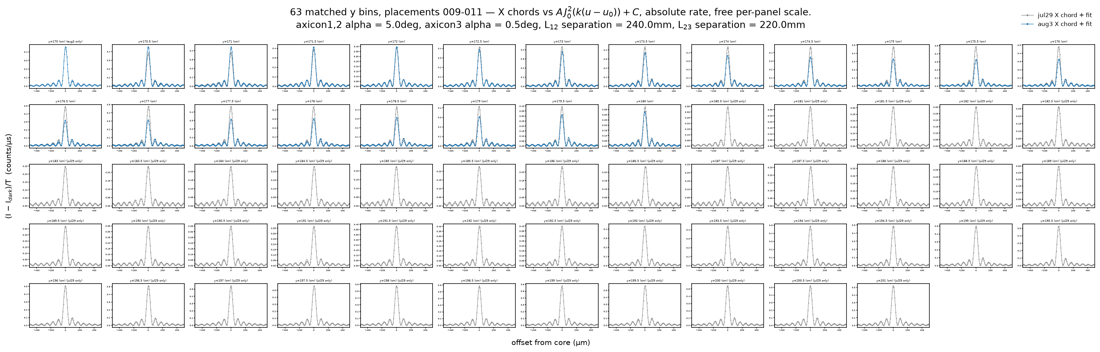

In [24]:
# --- overlay gallery: X chords, jul29 vs aug3 at matched y --------------------
# Preprocessing:
#   1. one panel per 0.5 cm y bin (union of both days); per (day, y bin)
#      keep the frame with the highest chord peak (best-centered core)
#   2. panels show the X chord only (dots) + its J0^2 fit (line), absolute
#      counts/us, free per-panel y limit — day-to-day amplitude AND shape
#      differences stay visible (kz is tracked in the k(y) cell instead)
#   3. panels with one day only are labelled accordingly
import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
from matplotlib.lines import Line2D

best_per = (fits_df.dropna(subset=["kx"])
            .sort_values("peak")
            .groupby(["day", "y_key"], observed=True).tail(1))
idx_of = {(r.day, r.y_key): r.Index for r in best_per.itertuples()}
y_bins = sorted(best_per["y_key"].unique())

N_COLS_CG = 13
n_rows_g = int(np.ceil(len(y_bins) / N_COLS_CG))
fig, axes = plt.subplots(n_rows_g, N_COLS_CG,
                         figsize=(1.6 * N_COLS_CG, 1.3 * n_rows_g),
                         squeeze=False)
u_fine = np.linspace(-497, 497, 400)
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, yb in zip(np.ravel(axes), y_bins):
    ax.set_axis_on()
    days_here = []
    for day in ("jul29", "aug3"):
        i = idx_of.get((day, yb))
        if i is None:
            continue
        f = chord_fits[i]
        days_here.append(day)
        c = DAY_COLOR[day]
        ax.plot(f["x_u"], f["Ix"], ".", ms=1.0, color=c, alpha=0.8)
        ax.plot(u_fine, j0sq_c(u_fine, *f["px"]), "-", color=c, lw=0.6)
    ax.set_xlim(-500, 500)
    ax.tick_params(labelsize=3, length=1.5, pad=1)
    tag = "" if len(days_here) == 2 else f" ({days_here[0]} only)"
    ax.set_title(f"y={yb:g} (cm){tag}", fontsize=4, pad=3)
fig.legend(handles=[
    Line2D([], [], color=DAY_COLOR["jul29"], marker=".", ms=3, lw=0.7,
           label="jul29 X chord + fit"),
    Line2D([], [], color=DAY_COLOR["aug3"], marker=".", ms=3, lw=0.7,
           label="aug3 X chord + fit")],
    loc="upper right", bbox_to_anchor=(0.999, 0.9935),
    fontsize=8, frameon=False)
fig.supxlabel("offset from core (µm)", fontsize=10, y=0.0015)
fig.supylabel("(I − I$_{dark}$)/T  (counts/µs)", fontsize=10, x=0.002)
fig.suptitle(f"{len(y_bins)} matched y bins, placements 009-011 — X chords vs "
             "$A\\,J_0^2(k(u-u_0))+C$, absolute rate, free per-panel scale.\n"
             + OPTIC_TITLE, y=0.9995, fontsize=13)
fig.tight_layout(pad=0.5, h_pad=1, w_pad=0.5, rect=(0.004, 0.003, 1, 0.9975))
save_fig("chords_overlay_gallery")
plt.close(fig)
with PILImage.open(IMAGES_DIR / "chords_overlay_gallery.png") as _im:
    _im.thumbnail((1100, 4400))
    _buf = io.BytesIO()
    _im.save(_buf, "png")
display(IPImage(data=_buf.getvalue()))

In [ ]:
# --- v3-style gallery: image + 1D comparison, jul29 vs aug3, per y target ----
# Recreates core_frame_gallery_v3.png (core-lobe notebook) as a day-to-day
# comparison — one row per y in Y_TARGETS_V3, FOUR panels:
#   [image jul29, image aug3, I/A_fit jul29, I/A_fit aug3]
# Preprocessing:
#   1. candidates = fully filled core frames (gal_df / rate_thumbs) within
#      +-1 cm of each Y_TARGETS_V3 entry (tolerance covers bins where the
#      exact y is in FRAME_EXCLUDE, e.g. jul29 170.0)
#   2. per candidate, in addition to the X/Z chords: radial profile =
#      azimuthal mean in 6.9 um bins about the sub-pixel centroid of the
#      5x5 block at the core; radial fit A*J0^2(k*r)+C with u0 FIXED at 0
#      — identical algorithm to the core-lobe notebook
#   3. per (y, day) keep the brightest frame by radial-fit amplitude A_fit
#   4. TWO figures from the same picks:
#      _rel_scale: profiles I / A_fit of their own frame; images to their
#                  own peak (shape comparison, day-to-day amplitude hidden)
#      _abs_scale: profiles in absolute rate (I - I_dark)/T with ONE shared
#                  y limit, images on ONE shared color scale (global peak)
#                  — day-to-day and y-to-y amplitude differences visible
#      (images sqrt-stretched in both)
#   5. a day with no data at that y (aug3 pending) -> empty panels
Y_TARGETS_V3 = np.arange(173, 180, 1)


def fit_radial(r_um, I):
    ok = np.isfinite(I) & (r_um <= FIT_HALF_UM)
    p0 = [np.nanmax(I[ok]), KR_IDEAL, 0.0, 0.0]
    lo = [0, 0.5 * KR_IDEAL, -1e-9, -np.inf]
    hi = [np.inf, 1.5 * KR_IDEAL, 1e-9, np.inf]
    try:
        popt, pcov = curve_fit(j0sq_c, r_um[ok], I[ok], p0=p0,
                               bounds=(lo, hi))
    except RuntimeError:
        return None, None, np.nan
    resid = I[ok] - j0sq_c(r_um[ok], *popt)
    return popt, np.sqrt(np.diag(pcov)), float(np.sqrt(np.mean(resid ** 2)) / popt[0])


cands = []
for i, (rt, f) in enumerate(zip(rate_thumbs, chord_fits)):
    dy = np.abs(f["y"] - Y_TARGETS_V3)
    if dy.min() > 1.0 or f["px"] is None:
        continue
    y_target = int(Y_TARGETS_V3[int(dy.argmin())])
    t = rt
    py, px = np.unravel_index(np.nanargmax(t), t.shape)
    # sub-pixel centroid of the 5x5 block at the core -> radial profile
    w = np.nan_to_num(t[max(py - 2, 0):py + 3, max(px - 2, 0):px + 3])
    wy, wx = np.mgrid[max(py - 2, 0):py + 3, max(px - 2, 0):px + 3]
    cy, cx = (w * wy).sum() / w.sum(), (w * wx).sum() / w.sum()
    yy, xx = np.mgrid[0:t.shape[0], 0:t.shape[1]]
    r_um = np.hypot(yy - cy, xx - cx) * UM_PER_PX_TH
    fin = np.isfinite(t)
    b = (r_um[fin] / UM_PER_PX_TH).astype(int)
    prof = (np.bincount(b, weights=t[fin]) / np.maximum(np.bincount(b), 1))
    r_cent = (np.arange(len(prof)) + 0.5) * UM_PER_PX_TH
    pr, perr_r, rms_r = fit_radial(r_cent, prof)
    if pr is None:
        continue
    cands.append(dict(i=i, y_target=y_target, r=r_cent, Ir=prof, pr=pr,
                      perr_r=perr_r, rms_r=rms_r, **f))

picks = {}   # (y0, day) -> nearest-y candidate, brightest radial-fit A
for c in cands:
    key = (c["y_target"], c["day"])
    # rank: exact y first (smaller |y - y_target|), then larger A_fit
    rank = (-abs(c["y"] - c["y_target"]), c["pr"][0])
    if key not in picks or rank > picks[key]["_rank"]:
        picks[key] = {**c, "_rank": rank}

rows_v3 = [y0 for y0 in Y_TARGETS_V3
           if any((y0, d) in picks for d in ("jul29", "aug3"))]
u_fine = np.linspace(-FIT_HALF_UM, FIT_HALF_UM, 500)
cmap_v3 = plt.get_cmap("inferno").copy()
cmap_v3.set_bad("0.25")

A_MAX_V3 = max(f["pr"][0] for f in picks.values())
VMAX_IMG_V3 = max(float(np.nanmax(rate_thumbs[f["i"]])) for f in picks.values())
Y_LABEL_V3 = "y = " + ", ".join(f"{y0:g}" for y0 in rows_v3) + " cm"


def draw_v3_gallery(absolute):
    fig, axes = plt.subplots(len(rows_v3), 4,
                             figsize=(16, 1.75 * len(rows_v3)), squeeze=False,
                             width_ratios=[1, 1, 2.1, 2.1])
    for y0, (ax_i1, ax_i2, ax_p1, ax_p2) in zip(rows_v3, axes):
        for day, ax_im, ax_pr in (("jul29", ax_i1, ax_p1),
                                  ("aug3", ax_i2, ax_p2)):
            f = picks.get((y0, day))
            if f is None:
                for ax in (ax_im, ax_pr):
                    ax.set_axis_off()
                    ax.text(0.5, 0.5, f"no {day} frame", transform=ax.transAxes,
                            ha="center", va="center", fontsize=8, color="0.5")
                continue
            t = rate_thumbs[f["i"]]
            vmax_im = VMAX_IMG_V3 if absolute else np.nanmax(t)
            ax_im.imshow(np.sqrt(np.clip(t / vmax_im, 0, 1)), cmap=cmap_v3,
                         vmin=0, vmax=1, interpolation="nearest",
                         extent=[-497, 497, -497, 497])
            ax_im.set_xticks([]); ax_im.set_yticks([])
            ax_im.set_xlabel("x (µm)", fontsize=9)
            ax_im.set_ylabel("z (µm)", fontsize=9)
            ax_im.set_title(f"y = {f['y']:g}cm, run={f['run']}", fontsize=7)

            A = f["pr"][0]
            s = 1.0 if absolute else A     # profile divisor
            ax_pr.plot(f["x_u"], f["Ix"] / s, ".", ms=2, color="tab:blue")
            ax_pr.plot(f["z_u"], f["Iz"] / s, ".", ms=2, color="tab:green")
            ax_pr.plot(f["r"], f["Ir"] / s, "-", color="0.2", lw=0.9)
            ax_pr.plot(-f["r"], f["Ir"] / s, "-", color="0.2", lw=0.9)
            ax_pr.plot(u_fine, j0sq_c(u_fine, *f["pr"]) / s, "-",
                       color="tab:red", lw=1.0, alpha=0.85)
            ax_pr.set_xlim(-FIT_HALF_UM, FIT_HALF_UM)
            if absolute:
                ax_pr.set_ylim(-0.05 * A_MAX_V3, 1.2 * A_MAX_V3)
                ax_pr.set_ylabel("(I − I$_{dark}$)/T (counts/µs)", fontsize=8)
            else:
                ax_pr.set_ylim(-0.05, 1.2)
                ax_pr.set_ylabel("I / A$_{fit}$", fontsize=9)
            ax_pr.tick_params(labelsize=7)
            ax_pr.minorticks_on()
            kdev = f["pr"][1] / KR_IDEAL - 1
            kerr = f["perr_r"][1] / KR_IDEAL
            ax_pr.set_title(
                f"{day}: $k_x${f['px'][1] / KR_IDEAL - 1:+.0%}, "
                f"$k_z$ = {f['pz'][1] / KR_IDEAL - 1:+.0%}, "
                f"$k_r$ = {kdev:+.1%} ± {kerr:.1%} vs. ideal. "
                f"rms/A_fit = {f['rms_r']:.3f}", fontsize=8)

    for ax in axes[-1][2:]:
        ax.set_xlabel("position (um) - X/Z chords and +/- r", fontsize=9)
    h = [plt.Line2D([], [], marker=".", ls="", color="tab:blue", label="X chord"),
         plt.Line2D([], [], marker=".", ls="", color="tab:green", label="Z chord"),
         plt.Line2D([], [], color="0.2", label="Radial (mean)"),
         plt.Line2D([], [], color="tab:red", label="J$_0^2$ fit to radial")]
    fig.legend(handles=h, loc="upper right", fontsize=8, ncol=2,
               bbox_to_anchor=(0.99, 0.955))
    scale_line = (
        "absolute rate (I - I$_{dark}$)/T, all images scaled to global peak \n " if absolute else
        "normalized to the radial fit amplitude A_fit in region +/- 450 "
        "µm about the Bessel core lobe.\n")
    fig.suptitle("Bessel core image comparison w/ 1D Bessel fn J$_0^2$ at "
                 + Y_LABEL_V3 + " after axicon 3 - jul29 (left pair) vs aug3 "
                 "(right pair).\n" + scale_line + OPTIC_TITLE,
                 fontsize=11, x=0.42, y=0.999)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    save_fig("core_frame_gallery_v3_by_day_"
             + ("abs_scale" if absolute else "rel_scale"))
    plt.show()


saved images/axicon3_placement_comparison_2026_08_03/core_frame_gallery_v3_by_day_rel_scale.png


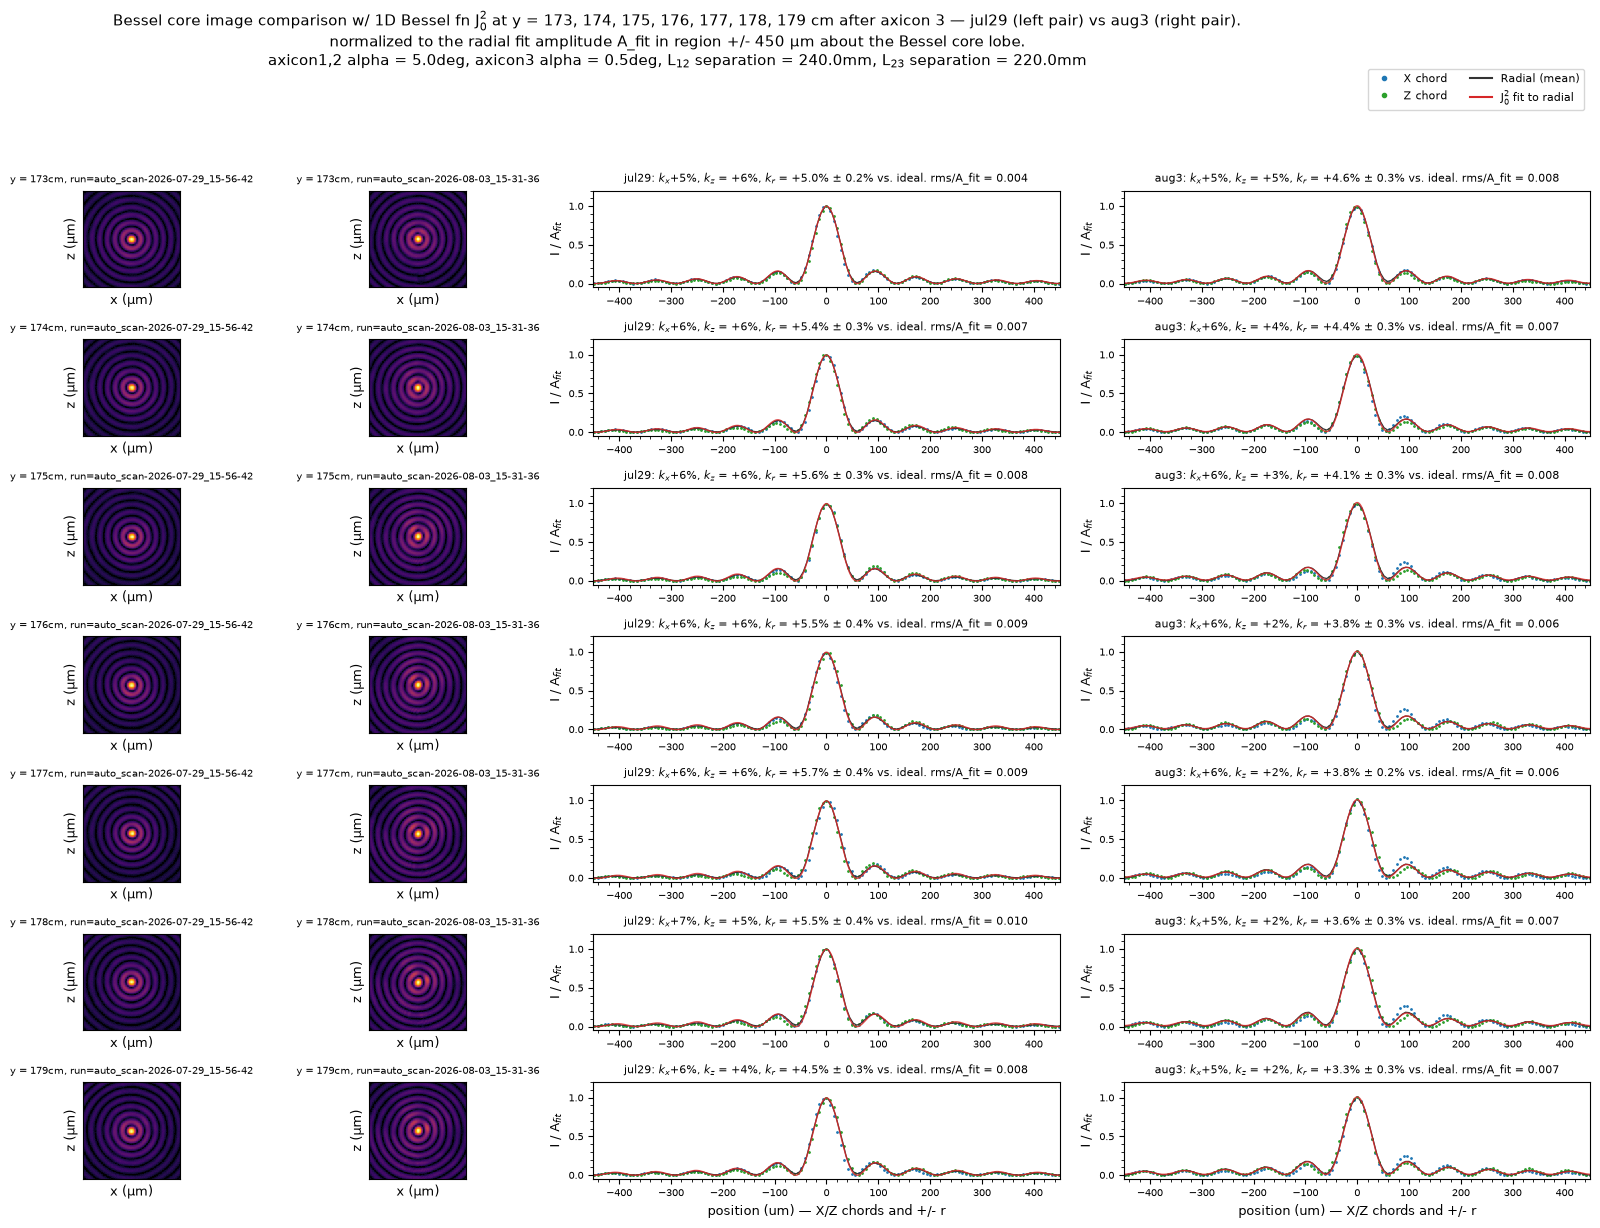

In [32]:
draw_v3_gallery(absolute=False)

saved images/axicon3_placement_comparison_2026_08_03/core_frame_gallery_v3_by_day_abs_scale.png


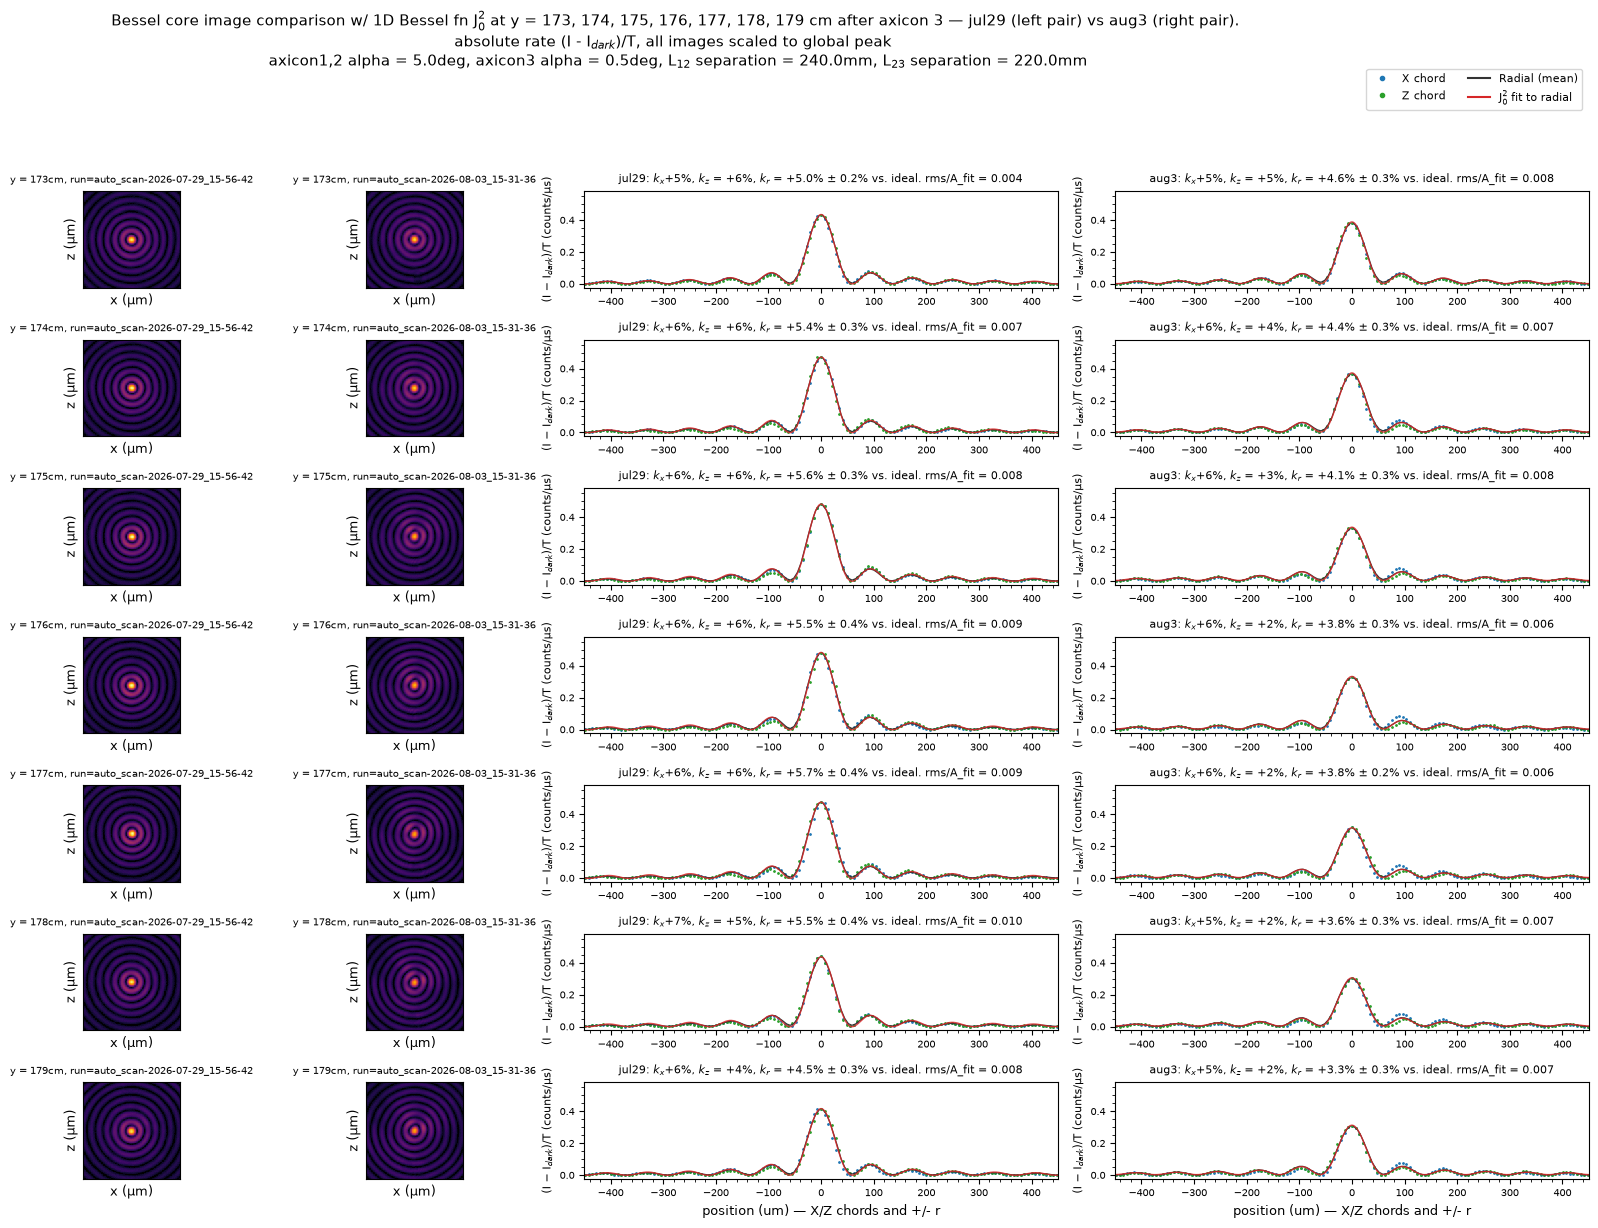

In [38]:
draw_v3_gallery(absolute=True)

saved images/axicon3_placement_comparison_2026_08_03/k_vs_y_by_day.png


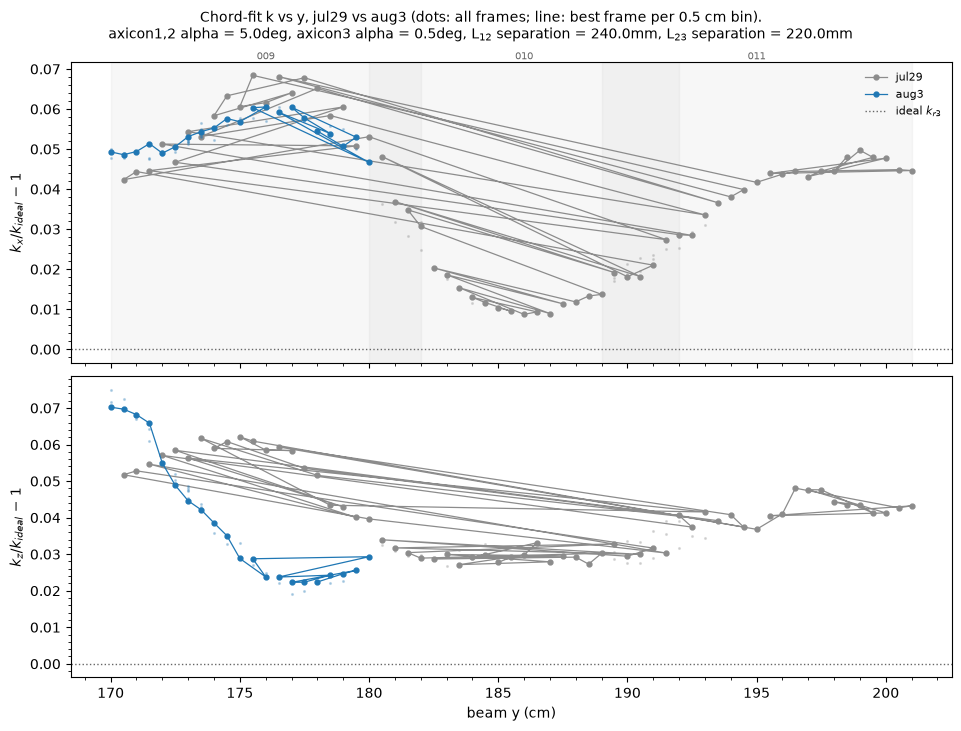

In [26]:
# --- k(y): jul29 vs aug3 ------------------------------------------------------
# Points = best frame per (day, y bin) from the gallery cell; faint dots =
# every fitted frame. Placement spans marked along the top.
PLACEMENT_SPANS = {"009": (170, 182), "010": (180, 192), "011": (189, 201)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7.2), sharex=True,
                               layout="constrained")
for ax, kcol, lab in ((ax1, "kx", "$k_x$"), (ax2, "kz", "$k_z$")):
    for day in ("jul29", "aug3"):
        c = DAY_COLOR[day]
        sub_all = fits_df[(fits_df["day"] == day)].dropna(subset=[kcol])
        sub_best = best_per[best_per["day"] == day].dropna(subset=[kcol])
        ax.plot(sub_all["y"], sub_all[kcol] / KR_IDEAL - 1, ".", ms=2.5,
                color=c, alpha=0.25)
        ax.plot(sub_best["y_key"], sub_best[kcol] / KR_IDEAL - 1, "o-",
                ms=3.5, lw=0.9, color=c, label=day)
    ax.axhline(0, color="0.4", ls=":", lw=1, label="ideal $k_{r3}$")
    ax.set_ylabel(f"{lab}/$k_{{ideal}}$ − 1")
    ax.minorticks_on()
ax1.legend(fontsize=8, frameon=False)
for num, (y0, y1) in PLACEMENT_SPANS.items():
    ax1.axvspan(y0, y1, color="0.5", alpha=0.06)
    ax1.text((y0 + y1) / 2, ax1.get_ylim()[1], num, fontsize=7,
             color="0.4", ha="center", va="bottom")
ax2.set_xlabel("beam y (cm)")
fig.suptitle("Chord-fit k vs y, jul29 vs aug3 (dots: all frames; line: best "
             "frame per 0.5 cm bin).\n" + OPTIC_TITLE, fontsize=10)
save_fig("k_vs_y_by_day")
plt.show()

saved images/axicon3_placement_comparison_2026_08_03/A_vs_y_by_day.png


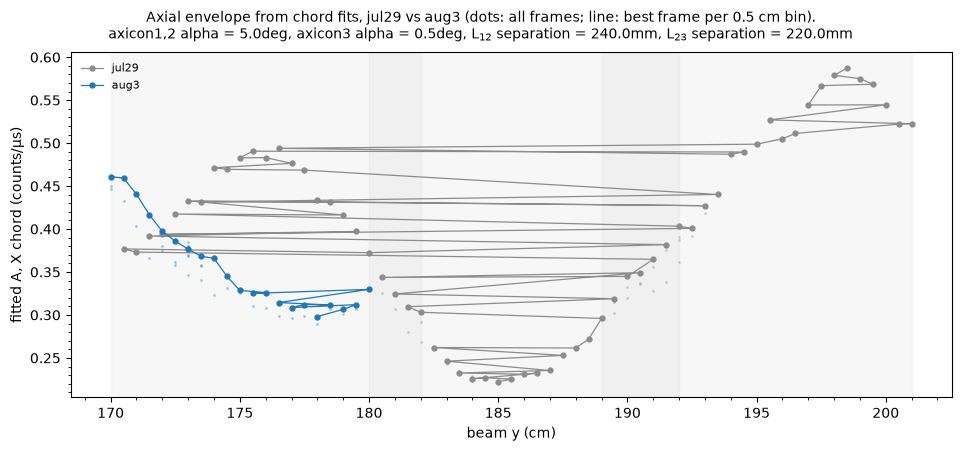

In [27]:
# --- A(y): axial envelope, jul29 vs aug3 --------------------------------------
# Fitted X-chord amplitude A (dark-corrected counts/us) = local envelope.
# The jul29 run saw real dips near 170 and 185 cm — the repeatability of
# those dips is the headline question for this comparison.
# NOTE: A inherits photometric systematics (servo exposure history, dark
# floor, alignment); dark-corrected rate should be day-comparable, but a
# global few-% scale offset between days is not meaningful.
fig, ax = plt.subplots(figsize=(9.5, 4.4), layout="constrained")
for day in ("jul29", "aug3"):
    c = DAY_COLOR[day]
    sub_all = fits_df[fits_df["day"] == day].dropna(subset=["Ax"])
    sub_best = best_per[best_per["day"] == day].dropna(subset=["Ax"])
    ax.plot(sub_all["y"], sub_all["Ax"], ".", ms=2.5, color=c, alpha=0.25)
    ax.plot(sub_best["y_key"], sub_best["Ax"], "o-", ms=3.5, lw=0.9,
            color=c, label=day)
for num, (y0, y1) in PLACEMENT_SPANS.items():
    ax.axvspan(y0, y1, color="0.5", alpha=0.06)
ax.set_xlabel("beam y (cm)")
ax.set_ylabel("fitted A, X chord (counts/µs)")
ax.minorticks_on()
ax.legend(fontsize=8, frameon=False)
fig.suptitle("Axial envelope from chord fits, jul29 vs aug3 (dots: all "
             "frames; line: best frame per 0.5 cm bin).\n" + OPTIC_TITLE,
             fontsize=10)
save_fig("A_vs_y_by_day")
plt.show()

20 matched y bins
median dk_x/k -0.31%, dk_z/k -1.84%, A_aug3/A_jul29 0.756
saved images/axicon3_placement_comparison_2026_08_03/paired_diffs_by_y.png


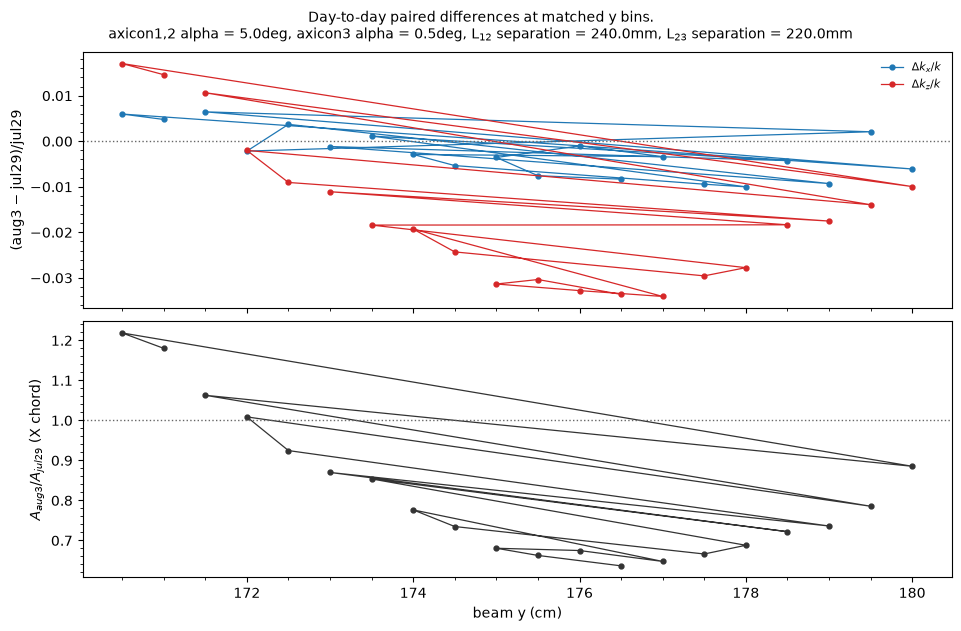

In [28]:
# --- paired differences at matched y bins ------------------------------------
#   1. inner-join the per-bin best frames of the two days on y_key
#   2. dk/k per chord axis + amplitude ratio aug3/jul29 per bin
#   3. medians printed; only bins with BOTH days contribute
b = best_per.set_index("y_key")
j = (b[b["day"] == "jul29"].add_suffix("_jul29")
     .join(b[b["day"] == "aug3"].add_suffix("_aug3"), how="inner"))
print(f"{len(j)} matched y bins")
if len(j):
    j = j.assign(
        dkx=(j["kx_aug3"] - j["kx_jul29"]) / j["kx_jul29"],
        dkz=(j["kz_aug3"] - j["kz_jul29"]) / j["kz_jul29"],
        A_ratio=j["Ax_aug3"] / j["Ax_jul29"])
    print(f"median dk_x/k {j['dkx'].median():+.2%}, "
          f"dk_z/k {j['dkz'].median():+.2%}, "
          f"A_aug3/A_jul29 {j['A_ratio'].median():.3f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True,
                                   layout="constrained")
    ax1.plot(j.index, j["dkx"], "o-", ms=3.5, lw=0.9, color="C0",
             label="$\\Delta k_x/k$")
    ax1.plot(j.index, j["dkz"], "o-", ms=3.5, lw=0.9, color="C3",
             label="$\\Delta k_z/k$")
    ax1.axhline(0, color="0.4", ls=":", lw=1)
    ax1.set_ylabel("(aug3 − jul29)/jul29")
    ax1.legend(fontsize=8, frameon=False)
    ax1.minorticks_on()
    ax2.plot(j.index, j["A_ratio"], "o-", ms=3.5, lw=0.9, color="0.2")
    ax2.axhline(1, color="0.4", ls=":", lw=1)
    ax2.set_ylabel("$A_{aug3}/A_{jul29}$ (X chord)")
    ax2.set_xlabel("beam y (cm)")
    ax2.minorticks_on()
    fig.suptitle("Day-to-day paired differences at matched y bins.\n"
                 + OPTIC_TITLE, fontsize=10)
    save_fig("paired_diffs_by_y")
    plt.show()

Rerun top-to-bottom as aug3 010/011 land (run discovery, dark stats, and thumbnails are incremental). Extend `FRAME_EXCLUDE` if aug3 shows washboard frames. Placement anchors are good to ±0.5 cm — a rigid Δy offset between days is possible on top of per-bin scatter.